In [171]:
#@title Imports, dependencies, MNIST download and transformation selection

#@title SNN and MLP on Backprop v Feedback Alignment
import os
import io
import math
import random
import contextlib
import numpy as np
import scipy
import warnings
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt

# IPython dependencies (if running in a notebook)
try:
    from IPython.display import Image, SVG, display
except ImportError:
    pass

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms

# snntorch dependencies
try:
    import snntorch as snn
    from snntorch import spikeplot as splt
    from snntorch import spikegen
except ImportError:
    print("snnTorch not found. Installing...")
    import subprocess
    subprocess.check_call(["pip", "install", "snntorch", "--quiet"])
    import snntorch as snn
    from snntorch import spikeplot as splt
    from snntorch import spikegen

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

class Config():
    def __init__(self):
        self.BATCH_SIZE = 128
        self.NUM_EPOCHS = 10 # Speed up training
        self.NUM_INPUTS = np.int64(28**2) # 28x28 images
        self.NUM_OUTPUTS = 3 #10 #3 #11
        self.NUM_HIDDEN = 100
        self.ACTIVATION = "leaky"
        self.BIAS = True

        self.BETA = 0.8 # Slope for leaky relu on SNN
        self.NUM_SNN_TIMESTEPS = 25

        self.ADAM_BETA = (0.9, 0.999)
        self.LEARNING_RULE = 3e-4

config = Config()

def download_mnist(train_prop=0.8, keep_prop=0.5, neuromatch_magic_normalize = 1):
    valid_prop = 1 - train_prop
    discard_prop = 1 - keep_prop

    if neuromatch_magic_normalize:
        norm_func = transforms.Normalize((0.1307,), (0.3081,))
    else:
        norm_func = transforms.Normalize((0,), (1,))

    transform = transforms.Compose([
              transforms.Resize((28, 28)),
              transforms.Grayscale(),
              transforms.ToTensor(),
              norm_func
              ])

    with contextlib.redirect_stdout(io.StringIO()):
        full_train_set = torchvision.datasets.MNIST(
            root="./data/", train=True, download=True, transform=transform,
        )
        full_test_set = torchvision.datasets.MNIST(
            root="./data/", train=False, download=True, transform=transform,
        )

    train_set, valid_set, _ = torch.utils.data.random_split(
        full_train_set,
        [train_prop * keep_prop, valid_prop * keep_prop, discard_prop]
    )
    test_set, _ = torch.utils.data.random_split(
        full_test_set,
        [keep_prop, discard_prop]
    )

    print("Number of examples retained:")
    print(f"  {len(train_set)} (training)")
    print(f"  {len(valid_set)} (validation)")
    print(f"  {len(test_set)} (test)")

    return train_set, valid_set, test_set

train_set, valid_set, test_set = download_mnist(train_prop=0.65,
                                                keep_prop=0.1,
                                                neuromatch_magic_normalize = 1)

BATCH_SIZE = config.BATCH_SIZE
train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
valid_loader = torch.utils.data.DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)


Number of examples retained:
  3900 (training)
  2100 (validation)
  1000 (test)


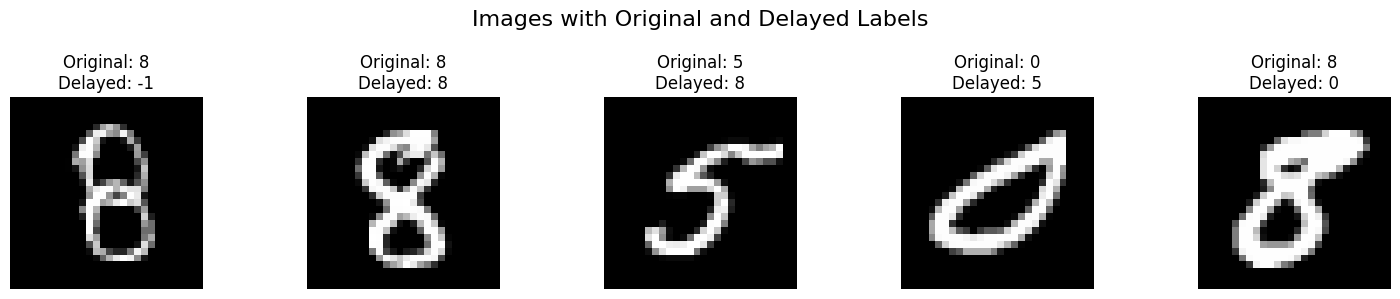

In [172]:
#@markdown Plot some example images to make sure everything is loaded in properly

# Get an example batch
images, labels = next(iter(train_loader))

# Select the first 5 images and labels
num_examples = 5
example_images = images[:num_examples]
example_labels = labels[:num_examples]

# Apply a forward shift to create 'delayed' labels
delayed_labels = torch.cat((torch.tensor([-1]), example_labels[:-1]))

fig, axs = plt.subplots(1, num_examples, figsize=(15, 3))
for i in range(num_examples):
    axs[i].imshow(example_images[i].squeeze().cpu().numpy(), cmap='gray')
    axs[i].set_title(f"Original: {example_labels[i].item()}\nDelayed: {delayed_labels[i].item()}")
    axs[i].axis("off")
fig.suptitle("Images with Original and Delayed Labels", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust layout to make space for suptitle
plt.show()

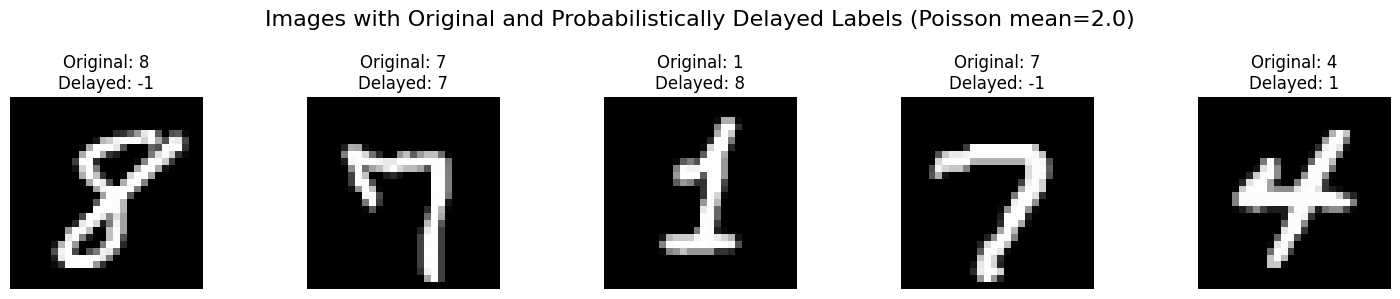

In [173]:
#@markdown Probabilitic label delay on MNIST classification example

import torch
import numpy as np
import matplotlib.pyplot as plt
import random

def apply_probabilistic_delayed_labels(original_labels, num_examples, delay_mean=1.0):
    """
    Applies a probabilistic forward shift to labels with conflict resolution.

    Args:
        original_labels (torch.Tensor): The original labels for the batch.
        num_examples (int): The number of examples in the batch (determines the size
                            of the delayed labels array).
        delay_mean (float): The mean (lambda) for the Poisson distribution to determine
                            the delay amount for each label.

    Returns:
        torch.Tensor: A tensor of the new, probabilistically delayed labels.
                      Labels that are pushed out of bounds or for unassigned slots are -1.
    """
    # Initialize delayed_labels with a special value indicating empty/no label
    delayed_labels = torch.full((num_examples,), -1, dtype=torch.long)

    # Store tuples of (original_index, desired_delay_amount, original_label_value)
    label_delay_info = []

    # 1. Generate desired delay amounts for each label
    for i, label in enumerate(original_labels):
        # Generate delay amount using Poisson distribution
        delay_amount = np.random.poisson(delay_mean)
        label_delay_info.append((i, delay_amount, label.item()))

    # Sort by original_index to ensure 'sequential resolution' based on original position.
    # The label that appeared earlier in the original batch has priority if they conflict.
    label_delay_info.sort(key=lambda x: x[0])

    # 2. Apply delays and resolve conflicts
    # Use a boolean array to track occupied slots for efficient checking
    occupied_slots = [False] * num_examples

    for original_idx, delay_amount, label_value in label_delay_info:
        desired_target_idx = original_idx + delay_amount

        # Find the next available slot for this label, starting from its desired position
        current_target_idx = desired_target_idx
        while current_target_idx < num_examples and occupied_slots[current_target_idx]:
            current_target_idx += 1

        # Place the label if a slot is found within bounds
        if current_target_idx < num_examples:
            delayed_labels[current_target_idx] = label_value
            occupied_slots[current_target_idx] = True
        # If current_target_idx >= num_examples, the label is effectively 'lost'
        # or pushed out of the window. Its corresponding slot in delayed_labels
        # will remain -1.

    return delayed_labels

# --- Example Usage ---

# Get an example batch from the DataLoader
images, labels = next(iter(train_loader))

# Select the first N images and labels for demonstration
num_examples_to_plot = 5 # You can adjust this number
example_images = images[:num_examples_to_plot]
example_labels = labels[:num_examples_to_plot]

# User can select the probability distribution parameters.
# Here, we use a Poisson distribution for delay_amount.
# 'delay_mean_param' titrates the average number of steps a label is delayed.
delay_mean_param = 2.0 # Adjust this value to change the average delay

prob_delayed_labels = apply_probabilistic_delayed_labels(
    example_labels, num_examples_to_plot, delay_mean=delay_mean_param
)

# Plotting the images with original and probabilistically delayed labels
fig, axs = plt.subplots(1, num_examples_to_plot, figsize=(15, 3))
for i in range(num_examples_to_plot):
    axs[i].imshow(example_images[i].squeeze().cpu().numpy(), cmap='gray')
    axs[i].set_title(f"Original: {example_labels[i].item()}\nDelayed: {prob_delayed_labels[i].item()}")
    axs[i].axis("off")
fig.suptitle(f"Images with Original and Probabilistically Delayed Labels (Poisson mean={delay_mean_param})", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust layout to make space for suptitle
plt.show()

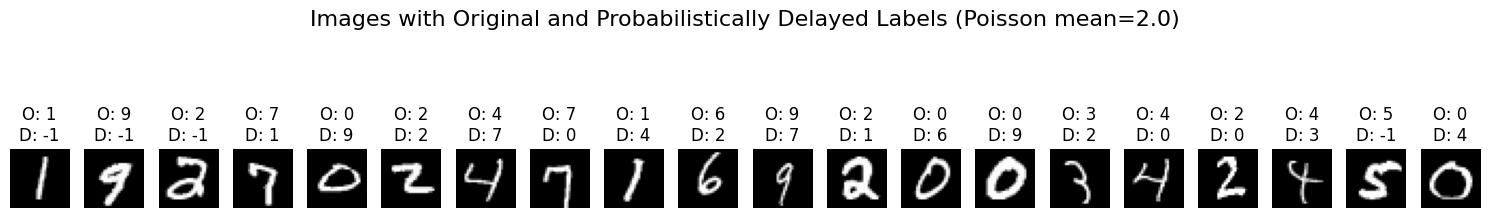

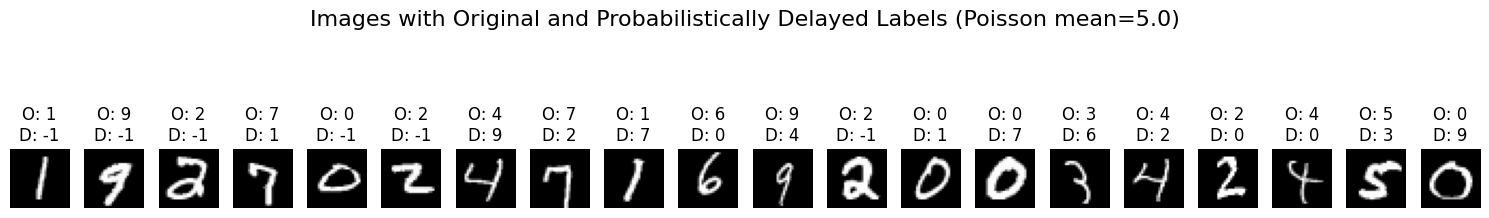

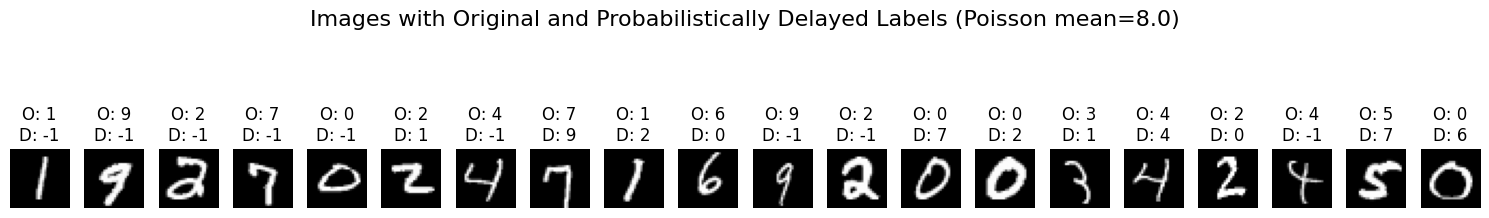

In [174]:
#@markdown 3 other examples, now a larger batch, each with different delay probabilities
#@markdown Avg. Delays are 2, 5 and 8 steps
# Get an example batch from the DataLoader
images, labels = next(iter(train_loader))

# Select the first N images and labels for demonstration
num_examples_to_plot = 20 # You can adjust this number
example_images = images[:num_examples_to_plot]
example_labels = labels[:num_examples_to_plot]

# User can select the probability distribution parameters.
# Here, we use a Poisson distribution for delay_amount.
# 'delay_mean_param' titrates the average number of steps a label is delayed.
delay_mean_param = 2.0 # Adjust this value to change the average delay

prob_delayed_labels = apply_probabilistic_delayed_labels(
    example_labels, num_examples_to_plot, delay_mean=delay_mean_param
)

# Plotting the images with original and probabilistically delayed labels
fig, axs = plt.subplots(1, num_examples_to_plot, figsize=(15, 3))
for i in range(num_examples_to_plot):
    axs[i].imshow(example_images[i].squeeze().cpu().numpy(), cmap='gray')
    axs[i].set_title(f"O: {example_labels[i].item()}\nD: {prob_delayed_labels[i].item()}")
    axs[i].axis("off")
fig.suptitle(f"Images with Original and Probabilistically Delayed Labels (Poisson mean={delay_mean_param})", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust layout to make space for suptitle
plt.show()



# Select the first N images and labels for demonstration
num_examples_to_plot = 20 # You can adjust this number
example_images = images[:num_examples_to_plot]
example_labels = labels[:num_examples_to_plot]

# User can select the probability distribution parameters.
# Here, we use a Poisson distribution for delay_amount.
# 'delay_mean_param' titrates the average number of steps a label is delayed.
delay_mean_param = 5.0 # Adjust this value to change the average delay

prob_delayed_labels = apply_probabilistic_delayed_labels(
    example_labels, num_examples_to_plot, delay_mean=delay_mean_param
)

# Plotting the images with original and probabilistically delayed labels
fig, axs = plt.subplots(1, num_examples_to_plot, figsize=(15, 3))
for i in range(num_examples_to_plot):
    axs[i].imshow(example_images[i].squeeze().cpu().numpy(), cmap='gray')
    axs[i].set_title(f"O: {example_labels[i].item()}\nD: {prob_delayed_labels[i].item()}")
    axs[i].axis("off")
fig.suptitle(f"Images with Original and Probabilistically Delayed Labels (Poisson mean={delay_mean_param})", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust layout to make space for suptitle
plt.show()

# Select the first N images and labels for demonstration
num_examples_to_plot = 20 # You can adjust this number
example_images = images[:num_examples_to_plot]
example_labels = labels[:num_examples_to_plot]

# User can select the probability distribution parameters.
# Here, we use a Poisson distribution for delay_amount.
# 'delay_mean_param' titrates the average number of steps a label is delayed.
delay_mean_param = 8.0 # Adjust this value to change the average delay

prob_delayed_labels = apply_probabilistic_delayed_labels(
    example_labels, num_examples_to_plot, delay_mean=delay_mean_param
)

# Plotting the images with original and probabilistically delayed labels
fig, axs = plt.subplots(1, num_examples_to_plot, figsize=(15, 3))
for i in range(num_examples_to_plot):
    axs[i].imshow(example_images[i].squeeze().cpu().numpy(), cmap='gray')
    axs[i].set_title(f"O: {example_labels[i].item()}\nD: {prob_delayed_labels[i].item()}")
    axs[i].axis("off")
fig.suptitle(f"Images with Original and Probabilistically Delayed Labels (Poisson mean={delay_mean_param})", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust layout to make space for suptitle
plt.show()

In [175]:

#@markdown `restrict_classes(dataset)`: Keeps specified classes in a dataset.

def restrict_classes(dataset, classes=[6], keep=True):
  """
  Removes or keeps specified classes in a dataset.

  Arguments:
  - dataset (torch dataset or subset): Dataset with class targets.
  - classes (list): List of classes to keep or remove.
  - keep (bool): If True, the classes specified are kept. If False, they are
  removed.

  Returns:
  - new_dataset (torch dataset or subset): Datset restricted as specified.
  """

  if hasattr(dataset, "dataset"):
    indices = np.asarray(dataset.indices)
    targets = dataset.dataset.targets[indices]
    dataset = dataset.dataset
  else:
    indices = np.arange(len(dataset))
    targets = dataset.targets

  specified_idxs = np.isin(targets, np.asarray(classes))
  if keep:
    retain_indices = indices[specified_idxs]
  else:
    retain_indices = indices[~specified_idxs]

  new_dataset = torch.utils.data.Subset(dataset, retain_indices)

  return new_dataset

In [186]:
#@markdown restrict classes and probabilistically forward-delay labels

import torch
import numpy as np
import matplotlib.pyplot as plt
import random
import warnings

def create_delayed_dataloader(original_dataloader, delay_mean, num_desired_labels=None, classes_to_filter=None):
    """
    Creates a new DataLoader that yields probabilistically delayed labels for each batch.
    Optionally, filters the dataset to include only a specified number of unique classes.

    Args:
        original_dataloader (torch.utils.data.DataLoader): The original DataLoader.
        delay_mean (float): The mean (lambda) for the Poisson distribution to determine
                            the delay amount for each label, used by
                            apply_probabilistic_delayed_labels.
        num_desired_labels (int, optional): If specified and `classes_to_filter` is None,
                                            the dataset will be filtered to include only
                                            this many randomly selected unique classes.
                                            Labels for these classes will be remapped to be 0-indexed.
                                            Defaults to None.
        classes_to_filter (list, optional): A specific list of class labels to filter the
                                            dataset by. If provided, this list overrides the
                                            random sampling based on `num_desired_labels`.
                                            Defaults to None.

    Returns:
        torch.utils.data.DataLoader: A new DataLoader yielding (images, delayed_labels).
    """

    dataset_for_loader = original_dataloader.dataset
    selected_classes_map = None # Initialize to None

    if num_desired_labels is not None or classes_to_filter is not None:
        if classes_to_filter is not None:
            selected_classes = classes_to_filter
            num_actual_output_classes = len(selected_classes)
            print(f"Dataset will be filtered to include *pre-selected* classes: {sorted(selected_classes)}")
        else:
            # Determine the effective labels of the dataset in the dataloader
            if isinstance(original_dataloader.dataset, torch.utils.data.Subset):
                # If it's a Subset, get labels from the base dataset through its indices
                base_dataset = original_dataloader.dataset.dataset
                current_subset_indices = original_dataloader.dataset.indices
                if hasattr(base_dataset, 'targets'):
                    all_labels_in_current_scope = [base_dataset.targets[i].item() for i in current_subset_indices]
                elif hasattr(base_dataset, 'labels'):
                    all_labels_in_current_scope = [base_dataset.labels[i].item() for i in current_subset_indices]
                else:
                    raise AttributeError("Underlying base dataset has no 'targets' or 'labels' attribute for filtering.")
            else:
                # If it's a direct dataset, get labels directly
                if hasattr(original_dataloader.dataset, 'targets'):
                    all_labels_in_current_scope = original_dataloader.dataset.targets.tolist()
                elif hasattr(original_dataloader.dataset, 'labels'):
                    all_labels_in_current_scope = original_dataloader.dataset.labels.tolist()
                else:
                    raise AttributeError("Dataset has no 'targets' or 'labels' attribute for filtering.")

            unique_classes_in_scope = torch.unique(torch.tensor(all_labels_in_current_scope)).tolist()

            if num_desired_labels > len(unique_classes_in_scope):
                print(f"Warning: num_desired_labels ({num_desired_labels}) is greater than available unique classes ({len(unique_classes_in_scope)}). Using all available classes.")
                selected_classes = unique_classes_in_scope
                num_actual_output_classes = len(unique_classes_in_scope)
            else:
                selected_classes = random.sample(unique_classes_in_scope, num_desired_labels)
                num_actual_output_classes = num_desired_labels

            print(f"Dataset will be filtered to include only classes: {sorted(selected_classes)}")

        print(f"If you are using models, you might need to update `config.NUM_OUTPUTS` to {num_actual_output_classes} accordingly.")

        # Create a mapping from original class labels to new 0-indexed labels
        selected_classes_map = {original_label: new_label for new_label, original_label in enumerate(sorted(selected_classes))}

        # Use the restrict_classes helper function
        dataset_for_loader = restrict_classes(original_dataloader.dataset, classes=selected_classes, keep=True)


    def custom_collate_fn(batch):
        # batch is a list of (image, original_label) tuples
        images = torch.stack([item[0] for item in batch])
        original_labels_raw = [item[1] for item in batch] # These are from the original dataset/subset

        # Apply remapping if filtering was applied
        if selected_classes_map:
            # The labels obtained from `item[1]` can be Tensors or Python ints,
            # handle both cases when accessing the class_mapping.
            original_labels_tensor = torch.tensor([
                selected_classes_map[label.item() if isinstance(label, torch.Tensor) else label]
                for label in original_labels_raw
            ])
        else:
            original_labels_tensor = torch.tensor(original_labels_raw)

        num_examples_in_batch = len(batch)
        delayed_labels = apply_probabilistic_delayed_labels(
            original_labels_tensor, num_examples_in_batch, delay_mean=delay_mean
        )

        return images, delayed_labels

    # Prepare arguments for the new DataLoader
    dataloader_kwargs = {
        'dataset': dataset_for_loader, # Use the potentially filtered dataset
        'num_workers': original_dataloader.num_workers,
        'collate_fn': custom_collate_fn,
        'pin_memory': original_dataloader.pin_memory,
        'timeout': original_dataloader.timeout,
        'worker_init_fn': original_dataloader.worker_init_fn
    }

    # Always set batch_size, drop_last, and shuffle, letting DataLoader create the appropriate sampler.
    # This avoids issues where the original sampler (which was tied to the original dataset length)
    # is passed directly to a DataLoader wrapping a new, possibly smaller, Subset.
    dataloader_kwargs['batch_size'] = original_dataloader.batch_size
    dataloader_kwargs['drop_last'] = original_dataloader.drop_last
    # Check if the original DataLoader was shuffled, and replicate that behavior.
    # DataLoader creates a RandomSampler if shuffle=True, and SequentialSampler otherwise.
    dataloader_kwargs['shuffle'] = original_dataloader.shuffle if hasattr(original_dataloader, 'shuffle') else False

    # If a batch_sampler was explicitly provided to the original DataLoader,
    # replicating its exact behavior with a filtered subset is non-trivial.
    # For now, we will proceed with the assumption that the DataLoader will internally
    # create a standard sampler (Random or Sequential) based on the 'shuffle' flag.
    # If the user used a custom `batch_sampler`, this might need further customization.
    # A warning is appropriate here if batch_sampler is not None, as we are ignoring it.
    if original_dataloader.batch_sampler is not None:
        warnings.warn("Original DataLoader has a custom `batch_sampler`. "
                      "For the filtered DataLoader, `batch_size`, `drop_last`, "
                      "and `shuffle` from the original DataLoader will be used "
                      "to create a standard internal sampler. The custom `batch_sampler` "
                      "will not be directly re-used.")

    return torch.utils.data.DataLoader(**dataloader_kwargs)

# Example Usage with num_desired_labels:
print("\nCreating a new train_loader with delayed labels (mean delay = 2.0) and 2 desired classes...")

# Update config.NUM_OUTPUTS before initializing models if filtering
# This is illustrative; in a real scenario, you'd modify config before model definition cells
# For this example, we'll just demonstrate the DataLoader output
original_num_outputs = config.NUM_OUTPUTS # Store original to restore later if needed
num_desired_classes_example = 2
# config.NUM_OUTPUTS = num_desired_classes_example + 1 # +1 for the -1 label if it counts as a class - commented out to avoid global side-effect in this example

delayed_train_loader_filtered = create_delayed_dataloader(
    train_loader, delay_mean=2.0, num_desired_labels=num_desired_classes_example
)

images_batch_filtered, delayed_labels_batch_filtered = next(iter(delayed_train_loader_filtered))

print(f"Shape of images batch (filtered): {images_batch_filtered.shape}")
print(f"Shape of delayed labels batch (filtered): {delayed_labels_batch_filtered.shape}")
print(f"First 10 delayed labels from the batch (filtered): {delayed_labels_batch_filtered[:10]}")
print(f"Unique delayed labels (filtered): {torch.unique(delayed_labels_batch_filtered)}")

# Restore original config.NUM_OUTPUTS if not intended for global change
# config.NUM_OUTPUTS = original_num_outputs # commented out for the same reason
# print(f"Restored config.NUM_OUTPUTS to {config.NUM_OUTPUTS}")

print("\nCreating a new train_loader with delayed labels (mean delay = 2.0) without filtering...")

# Create a new DataLoader with probabilistic delayed labels for the training set (no filtering)
delayed_train_loader_unfiltered = create_delayed_dataloader(train_loader, delay_mean=2.0)

# Get an example batch from the new delayed dataloader
images_batch_unfiltered, delayed_labels_batch_unfiltered = next(iter(delayed_train_loader_unfiltered))

print(f"Shape of images batch: {images_batch_unfiltered.shape}")
print(f"Shape of delayed labels batch: {delayed_labels_batch_unfiltered.shape}")
print(f"First 10 delayed labels from the batch: {delayed_labels_batch_unfiltered[:10]}")
print(f"Unique delayed labels (unfiltered): {torch.unique(delayed_labels_batch_unfiltered)}")

# You can now use `delayed_train_loader_filtered` or `delayed_train_loader_unfiltered` for training with the new label structure.


Creating a new train_loader with delayed labels (mean delay = 2.0) and 2 desired classes...
Dataset will be filtered to include only classes: [0, 9]
If you are using models, you might need to update `config.NUM_OUTPUTS` to 2 accordingly.
Shape of images batch (filtered): torch.Size([128, 1, 28, 28])
Shape of delayed labels batch (filtered): torch.Size([128])
First 10 delayed labels from the batch (filtered): tensor([-1, -1,  0,  1,  1,  1,  1,  1, -1, -1])
Unique delayed labels (filtered): tensor([-1,  0,  1])

Creating a new train_loader with delayed labels (mean delay = 2.0) without filtering...
Shape of images batch: torch.Size([128, 1, 28, 28])
Shape of delayed labels batch: torch.Size([128])
First 10 delayed labels from the batch: tensor([0, 3, 1, 3, 6, 1, 3, 3, 5, 2])
Unique delayed labels (unfiltered): tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


/tmp/ipykernel_769/2758462264.py:132: UserWarning: Original DataLoader has a custom `batch_sampler`. For the filtered DataLoader, `batch_size`, `drop_last`, and `shuffle` from the original DataLoader will be used to create a standard internal sampler. The custom `batch_sampler` will not be directly re-used.
  warnings.warn("Original DataLoader has a custom `batch_sampler`. "


Dataset will be filtered to include only classes: [0, 6]
If you are using models, you might need to update `config.NUM_OUTPUTS` to 2 accordingly.


/tmp/ipykernel_769/2758462264.py:132: UserWarning: Original DataLoader has a custom `batch_sampler`. For the filtered DataLoader, `batch_size`, `drop_last`, and `shuffle` from the original DataLoader will be used to create a standard internal sampler. The custom `batch_sampler` will not be directly re-used.
  warnings.warn("Original DataLoader has a custom `batch_sampler`. "


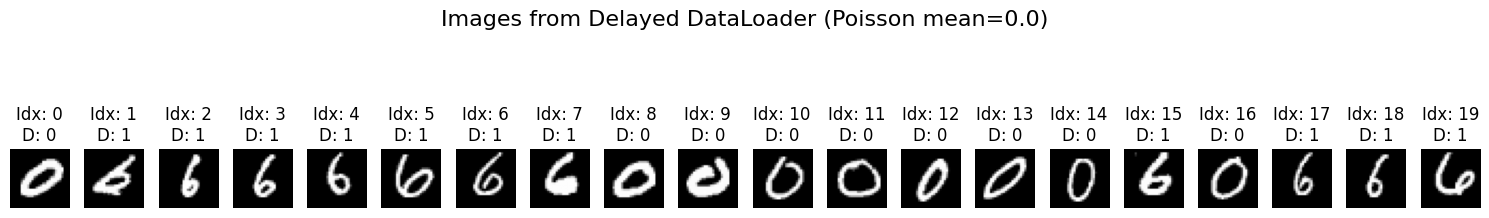

Dataset will be filtered to include only classes: [2, 6]
If you are using models, you might need to update `config.NUM_OUTPUTS` to 2 accordingly.


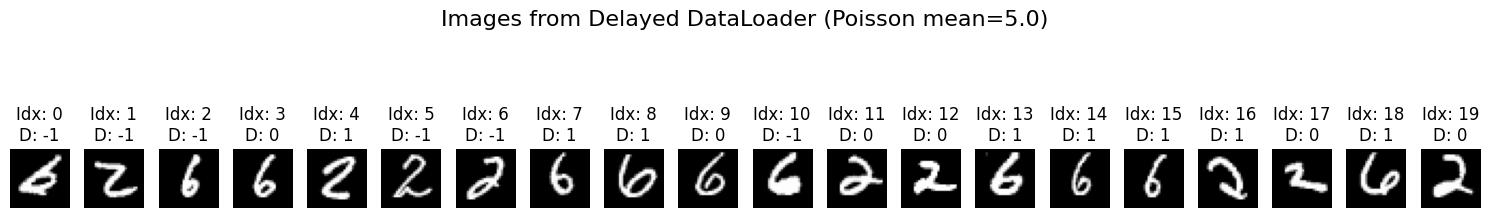

Dataset will be filtered to include only classes: [3, 7]
If you are using models, you might need to update `config.NUM_OUTPUTS` to 2 accordingly.


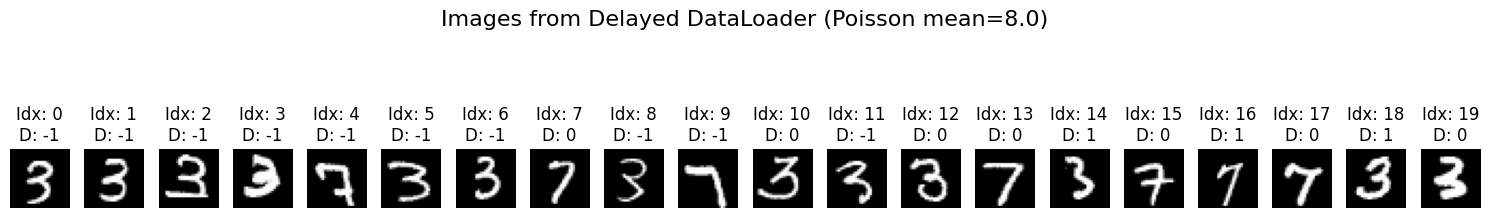

In [187]:
#@markdown 3 other examples, now a larger batch, each with different delay probabilities
#@markdown Avg. Delays are 2, 5 and 8 steps

# This cell replicates the visualization from a previous example (cell `uLDhLup_jKR2`),
# demonstrating probabilistic label delays using the 'apply_probabilistic_delayed_labels' function.

# --- Example with delay_mean_param = 2.0 ---
# Create a delayed dataloader for this delay mean
delay_mean_param_2 = 0.0
delayed_train_loader_2 = create_delayed_dataloader(train_loader, delay_mean=delay_mean_param_2, num_desired_labels=2)

# Get an example batch from the delayed DataLoader
images, prob_delayed_labels = next(iter(delayed_train_loader_2))

# Since the labels from the delayed_train_loader are already probabilistically delayed,
# we need to get the original labels from the dataset directly for comparison in the title.
# This assumes the dataset is wrapped in the dataloader.

num_examples_to_plot = 20 # You can adjust this number
example_images = images[:num_examples_to_plot]
# To get original labels, we would ideally need to store them or retrieve them
# from the original dataset. For now, we will use the delayed labels directly in the plot title.
# The 'O:' will represent the index in the batch, and 'D:' will be the delayed label.

# Plotting the images with probabilistically delayed labels
fig, axs = plt.subplots(1, num_examples_to_plot, figsize=(15, 3))
for i in range(num_examples_to_plot):
    axs[i].imshow(example_images[i].squeeze().cpu().numpy(), cmap='gray')
    axs[i].set_title(f"Idx: {i}\nD: {prob_delayed_labels[i].item()}")
    axs[i].axis("off")
fig.suptitle(f"Images from Delayed DataLoader (Poisson mean={delay_mean_param_2})", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust layout to make space for suptitle
plt.show()


# --- Example with delay_mean_param = 5.0 ---
# Create a delayed dataloader for this delay mean
delay_mean_param_5 = 5.0
delayed_train_loader_5 = create_delayed_dataloader(train_loader, delay_mean=delay_mean_param_5, num_desired_labels=2)

# Get an example batch from the delayed DataLoader
images, prob_delayed_labels = next(iter(delayed_train_loader_5))

num_examples_to_plot = 20 # You can adjust this number
example_images = images[:num_examples_to_plot]

# Plotting the images with probabilistically delayed labels
fig, axs = plt.subplots(1, num_examples_to_plot, figsize=(15, 3))
for i in range(num_examples_to_plot):
    axs[i].imshow(example_images[i].squeeze().cpu().numpy(), cmap='gray')
    axs[i].set_title(f"Idx: {i}\nD: {prob_delayed_labels[i].item()}")
    axs[i].axis("off")
fig.suptitle(f"Images from Delayed DataLoader (Poisson mean={delay_mean_param_5})", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust layout to make space for suptitle
plt.show()

# --- Example with delay_mean_param = 8.0 ---
# Create a delayed dataloader for this delay mean
delay_mean_param_8 = 8.0
delayed_train_loader_8 = create_delayed_dataloader(train_loader, delay_mean=delay_mean_param_8, num_desired_labels=2)

# Get an example batch from the delayed DataLoader
images, prob_delayed_labels = next(iter(delayed_train_loader_8))

num_examples_to_plot = 20 # You can adjust this number
example_images = images[:num_examples_to_plot]

# Plotting the images with probabilistically delayed labels
fig, axs = plt.subplots(1, num_examples_to_plot, figsize=(15, 3))
for i in range(num_examples_to_plot):
    axs[i].imshow(example_images[i].squeeze().cpu().numpy(), cmap='gray')
    axs[i].set_title(f"Idx: {i}\nD: {prob_delayed_labels[i].item()}")
    axs[i].axis("off")
fig.suptitle(f"Images from Delayed DataLoader (Poisson mean={delay_mean_param_8})", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust layout to make space for suptitle
plt.show()

In [178]:
#@markdown Define models for MLP and SNN feedforward networks.
#@markdown They will be trained with backprop for now

class MultiLayerPerceptron(torch.nn.Module):
    def __init__(self, num_inputs=config.NUM_INPUTS, num_hidden=config.NUM_HIDDEN, num_outputs=config.NUM_OUTPUTS, activation_type="leaky", bias=False):
        super().__init__()
        self.num_inputs = num_inputs
        self.num_hidden = num_hidden
        self.num_outputs = num_outputs
        self.bias = bias

        self.lin1 = torch.nn.Linear(num_inputs, num_hidden, bias=bias)
        self.lin2 = torch.nn.Linear(num_hidden, num_outputs, bias=bias)
        self.activation = torch.nn.LeakyReLU(config.BETA)

    def forward(self, X, y=None):
        h = self.activation(self.lin1(X.reshape(-1, self.num_inputs)))
        y_pred = self.lin2(h)
        return y_pred

class SNN_MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(config.NUM_INPUTS, config.NUM_HIDDEN)
        self.lif1 = snn.Leaky(beta=config.BETA)
        self.fc2 = nn.Linear(config.NUM_HIDDEN, config.NUM_OUTPUTS)
        self.lif2 = snn.Leaky(beta=config.BETA)

    def forward(self, x):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        spk2_rec, mem2_rec = [], []

        for step in range(config.NUM_SNN_TIMESTEPS):
            cur1 = self.fc1(x)
            spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            spk2_rec.append(spk2)
            mem2_rec.append(mem2)

        return torch.stack(spk2_rec, dim=0), torch.stack(mem2_rec, dim=0)


In [179]:
#@markdown Define models for recurrent networks.
#@markdown They will be trained with backprop for now

#### TODO: add recurrent MLP
# class RecurrentPerceptron(torch.nn.Module):
#     def __init__(self, num_inputs=config.NUM_INPUTS, num_hidden=config.NUM_HIDDEN, num_outputs=config.NUM_OUTPUTS, activation_type="leaky", bias=False):


class SNN_rec(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(config.NUM_INPUTS, config.NUM_HIDDEN)
        self.lif1 = snn.RLeaky(beta=config.BETA, linear_features=config.NUM_HIDDEN,
                                all_to_all=True
                               )
        self.fc2 = nn.Linear(config.NUM_HIDDEN, config.NUM_OUTPUTS)
        self.lif2 = snn.RLeaky(beta=config.BETA, linear_features=config.NUM_OUTPUTS, # Changed from config.NUM_HIDDEN to config.NUM_OUTPUTS
                                all_to_all=True
                               )

    def forward(self, x):
        spk1,mem1 = self.lif1.init_rleaky()
        spk2,mem2 = self.lif1.init_rleaky()
        spk2_rec, mem2_rec = [], []

        for step in range(config.NUM_SNN_TIMESTEPS):
            cur1 = self.fc1(x)
            spk1, mem1 = self.lif1(cur1, spk1, mem1)
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, spk2, mem2)
            spk2_rec.append(spk2)
            mem2_rec.append(mem2)

        return torch.stack(spk2_rec, dim=0), torch.stack(mem2_rec, dim=0)

In [180]:
#@markdown define training loops, optimizers and instantiate models

def train_snn_model(model, optimizer, train_loader, test_loader, num_epochs=config.NUM_EPOCHS):
    """
    Generic training loop for SNNs (works for both standard and Feedback Alignment).
    """
    model.to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=-1)
    loss_hist, test_loss_hist = [], []
    train_acc_hist, test_acc_hist = [], []
    num_steps = config.NUM_SNN_TIMESTEPS

    for epoch in range(num_epochs):
        for iter_counter, (data, targets) in enumerate(train_loader):
            data, targets = data.to(device), targets.to(device)

            # Forward pass
            model.train()
            spk_rec, mem_rec = model(data.view(config.BATCH_SIZE, -1))

            # Loss and updates
            loss_val = torch.zeros((1), dtype=torch.float, device=device)
            for step in range(num_steps):
                loss_val += criterion(mem_rec[step], targets)
            loss_val /= num_steps

            optimizer.zero_grad()
            loss_val.backward()
            optimizer.step()

            # Train Tracking
            loss_hist.append(loss_val.item())
            _, predicted_train_labels = spk_rec.sum(dim=0).max(1)
            train_acc = (predicted_train_labels == targets).float().mean().item()
            train_acc_hist.append(train_acc)

            # Test Tracking
            with torch.no_grad():
                model.eval()
                test_data, test_targets = next(iter(test_loader))
                test_data, test_targets = test_data.to(device), test_targets.to(device)

                test_spk, test_mem = model(test_data.view(config.BATCH_SIZE, -1))
                test_loss = torch.zeros((1), dtype=torch.float, device=device)
                for step in range(num_steps):
                     test_loss += criterion(test_mem[step], test_targets)
                test_loss /= num_steps
                test_loss_hist.append(test_loss.item())

                _, predicted_test_labels = test_spk.sum(dim=0).max(1)
                test_acc = (predicted_test_labels == test_targets).float().mean().item()
                test_acc_hist.append(test_acc)

    return loss_hist, test_loss_hist, train_acc_hist, test_acc_hist


def train_mlp_model(model, optimizer, train_loader, test_loader, num_epochs=config.NUM_EPOCHS):
    """
    Generic training loop for MLPs (works for both standard and Feedback Alignment).
    """
    model.to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=-1)
    loss_hist, test_loss_hist = [], []
    train_acc_hist, test_acc_hist = [], []

    for epoch in range(num_epochs):
        for iter_counter, (data, targets) in enumerate(train_loader):
            data, targets = data.to(device), targets.to(device)

            # Forward pass
            model.train()
            y_pred = model(data.view(config.BATCH_SIZE, -1))

            # Loss and Updates
            loss_val = criterion(y_pred, targets)
            optimizer.zero_grad()
            loss_val.backward()
            optimizer.step()

            # Train Tracking
            loss_hist.append(loss_val.item())
            predicted_train_labels = torch.argmax(y_pred, dim=1)
            train_acc = (predicted_train_labels == targets).float().mean().item()
            train_acc_hist.append(train_acc)

            # Test Tracking
            with torch.no_grad():
                model.eval()
                test_data, test_targets = next(iter(test_loader))
                test_data, test_targets = test_data.to(device), test_targets.to(device)

                test_y_pred = model(test_data.view(config.BATCH_SIZE, -1))
                test_loss = criterion(test_y_pred, test_targets)
                test_loss_hist.append(test_loss.item())

                predicted_test_labels = torch.argmax(test_y_pred, dim=1)
                test_acc = (predicted_test_labels == test_targets).float().mean().item()
                test_acc_hist.append(test_acc)

    return loss_hist, test_loss_hist, train_acc_hist, test_acc_hist


# # 1. Standard Backprop Models
# print("--> Initializing Standard Backprop Models...")
# mlp_bp = MultiLayerPerceptron(num_hidden=config.NUM_HIDDEN, bias=config.BIAS).to(device)
# snn_bp = SNN_MLP().to(device)

# mlp_bp_optimizer = torch.optim.Adam(mlp_bp.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)
# snn_bp_optimizer = torch.optim.Adam(snn_bp.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)

In [181]:
#@markdown define training loops, optimizers and instantiate Recurrent models

# 1. Standard Backprop Models
print("--> Initializing Backprop Models...")
mlp_bp = MultiLayerPerceptron(num_hidden=config.NUM_HIDDEN, bias=config.BIAS).to(device)
snn_bp = SNN_MLP().to(device)
rec_snn_bp = SNN_rec().to(device)

mlp_bp_optimizer = torch.optim.Adam(mlp_bp.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)
snn_bp_optimizer = torch.optim.Adam(snn_bp.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)
rec_snn_bp_optimizer = torch.optim.Adam(rec_snn_bp.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)

--> Initializing Backprop Models...


In [194]:
#@title hope this works... (Delay = 2)
delay_mean_param_2 = 0.01
num_desired_labels_for_all = 2 # Define the number of desired labels centrally

# --- Determine common selected classes from the train_loader's dataset ---
# This logic extracts unique classes from the *base* dataset if it's a Subset
if isinstance(train_loader.dataset, torch.utils.data.Subset):
    base_train_dataset = train_loader.dataset.dataset
    if hasattr(base_train_dataset, 'targets'):
        all_labels_from_train_scope = [base_train_dataset.targets[i].item() for i in train_loader.dataset.indices]
    elif hasattr(base_train_dataset, 'labels'):
        all_labels_from_train_scope = [base_train_dataset.labels[i].item() for i in train_loader.dataset.indices]
    else:
        raise AttributeError("Train dataset has no 'targets' or 'labels' attribute for filtering.")
else:
    if hasattr(train_loader.dataset, 'targets'):
        all_labels_from_train_scope = train_loader.dataset.targets.tolist()
    elif hasattr(train_loader.dataset, 'labels'):
        all_labels_from_train_scope = train_loader.dataset.labels.tolist()
    else:
        raise AttributeError("Train dataset has no 'targets' or 'labels' attribute for filtering.")

unique_classes_from_train_set = torch.unique(torch.tensor(all_labels_from_train_scope)).tolist()

if num_desired_labels_for_all > len(unique_classes_from_train_set):
    common_selected_classes = unique_classes_from_train_set
    print(f"Warning: num_desired_labels ({num_desired_labels_for_all}) is greater than available unique classes in train set ({len(unique_classes_from_train_set)}). Using all available classes.")
else:
    common_selected_classes = random.sample(unique_classes_from_train_set, num_desired_labels_for_all)

print(f"Common classes selected for all loaders: {sorted(common_selected_classes)}")

# --- Create delayed dataloaders using the common selected classes ---
delayed_train_loader_2 = create_delayed_dataloader(
    train_loader, delay_mean=delay_mean_param_2, classes_to_filter=common_selected_classes
)
delayed_val_loader_2 = create_delayed_dataloader(
    valid_loader, delay_mean=delay_mean_param_2, classes_to_filter=common_selected_classes
)
delayed_test_loader_2 = create_delayed_dataloader(
    test_loader, delay_mean=delay_mean_param_2, classes_to_filter=common_selected_classes
)

print("Training Recurrent SNN (Backprop)...")
rec_snn_bp_loss, rec_snn_bp_tloss, rec_snn_bp_acc, rec_snn_bp_tacc = train_snn_model(
    rec_snn_bp, rec_snn_bp_optimizer, delayed_train_loader_2, delayed_test_loader_2
)

print("Training MLP (Backprop)...")
mlp_bp_loss, mlp_bp_tloss, mlp_bp_acc, mlp_bp_tacc = train_mlp_model(
    mlp_bp, mlp_bp_optimizer, delayed_train_loader_2, delayed_test_loader_2
)

print("Training SNN (Backprop)...")
snn_bp_loss, snn_bp_tloss, snn_bp_acc, snn_bp_tacc = train_snn_model(
    snn_bp, snn_bp_optimizer, delayed_train_loader_2, delayed_test_loader_2
)

# #@title hope this works... (Delay = 2)
# delay_mean_param_2 = 1.0
# delayed_train_loader_2 = create_delayed_dataloader(train_loader, delay_mean=delay_mean_param_2, num_desired_labels=2)
# delayed_val_loader_2 = create_delayed_dataloader(valid_loader, delay_mean=delay_mean_param_2, num_desired_labels=2)
# delayed_test_loader_2 = create_delayed_dataloader(test_loader, delay_mean=delay_mean_param_2, num_desired_labels=2)

# print("Training Recurrent SNN (Backprop)...")
# # rec_snn_bp_loss, rec_snn_bp_tloss, rec_snn_bp_acc, rec_snn_bp_tacc = train_snn_model(
# #     rec_snn_bp, rec_snn_bp_optimizer, delayed_train_loader_2, delayed_test_loader_2
# # )
# rec_snn_bp_loss, rec_snn_bp_tloss, rec_snn_bp_acc, rec_snn_bp_tacc = train_snn_model(
#     rec_snn_bp, rec_snn_bp_optimizer, train_loader, test_loader
# )


# print("Training MLP (Backprop)...")
# # mlp_bp_loss, mlp_bp_tloss, mlp_bp_acc, mlp_bp_tacc = train_mlp_model(
# #     mlp_bp, mlp_bp_optimizer, delayed_train_loader_2, delayed_test_loader_2
# # )

# mlp_bp_loss, mlp_bp_tloss, mlp_bp_acc, mlp_bp_tacc = train_mlp_model(
#     mlp_bp, mlp_bp_optimizer, train_loader, test_loader
# )

# print("Training SNN (Backprop)...")
# # snn_bp_loss, snn_bp_tloss, snn_bp_acc, snn_bp_tacc = train_snn_model(
# #     snn_bp, snn_bp_optimizer, delayed_train_loader_2, delayed_test_loader_2
# # )

# snn_bp_loss, snn_bp_tloss, snn_bp_acc, snn_bp_tacc = train_snn_model(
#     snn_bp, snn_bp_optimizer, train_loader, test_loader
# )




Common classes selected for all loaders: [0, 2]
Dataset will be filtered to include *pre-selected* classes: [0, 2]
If you are using models, you might need to update `config.NUM_OUTPUTS` to 2 accordingly.
Dataset will be filtered to include *pre-selected* classes: [0, 2]
If you are using models, you might need to update `config.NUM_OUTPUTS` to 2 accordingly.
Dataset will be filtered to include *pre-selected* classes: [0, 2]
If you are using models, you might need to update `config.NUM_OUTPUTS` to 2 accordingly.
Training Recurrent SNN (Backprop)...


/tmp/ipykernel_769/2758462264.py:132: UserWarning: Original DataLoader has a custom `batch_sampler`. For the filtered DataLoader, `batch_size`, `drop_last`, and `shuffle` from the original DataLoader will be used to create a standard internal sampler. The custom `batch_sampler` will not be directly re-used.
  warnings.warn("Original DataLoader has a custom `batch_sampler`. "


Training MLP (Backprop)...
Training SNN (Backprop)...


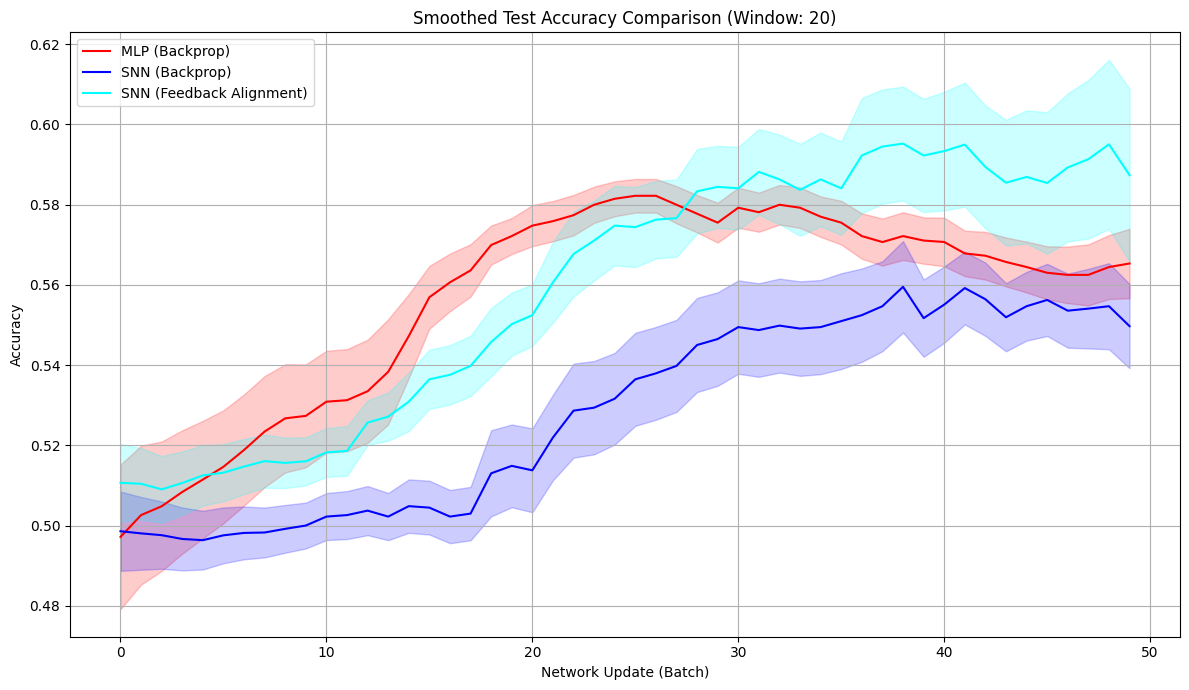

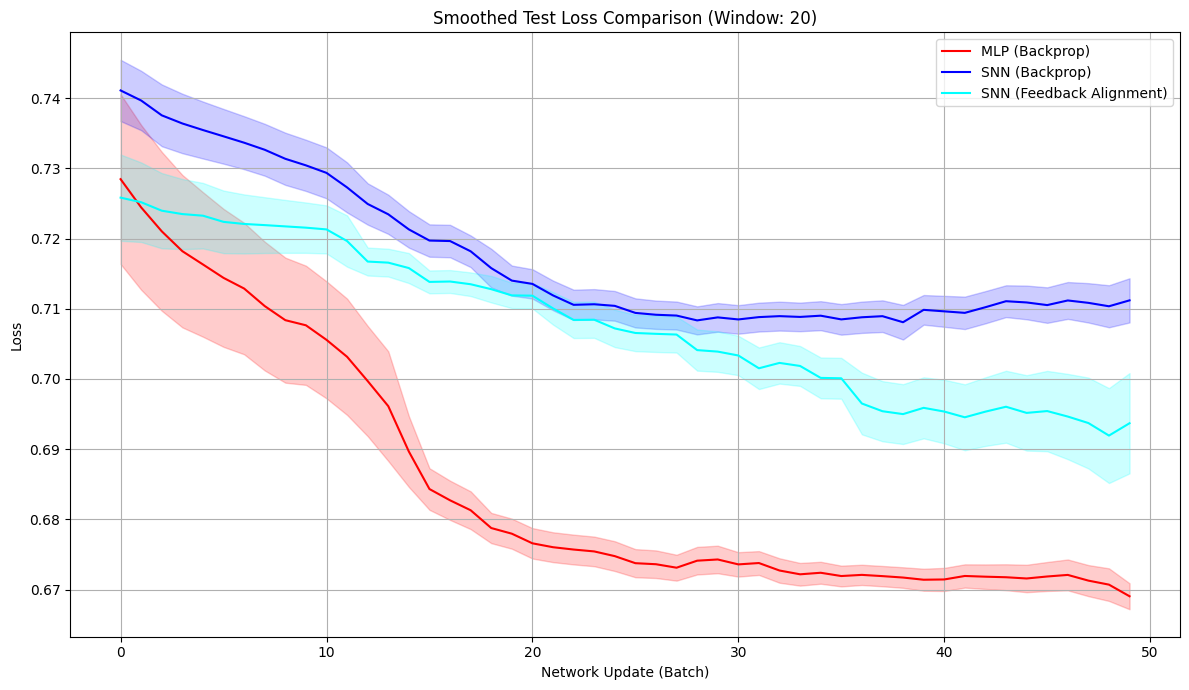

In [193]:
#@markdown plot results
def smooth_curve_with_sem(data, window_size):
    """
    Computes a moving average and the Standard Error of the Mean (SEM)
    over a sliding window to generate smooth trendlines and shaded confidence regions.
    """
    if window_size <= 1:
        return np.array(data), np.zeros(len(data))
    if len(data) < window_size:
        return np.array([np.mean(data)] * len(data)), np.array([np.std(data)/np.sqrt(len(data))] * len(data))

    smoothed_data = []
    sem_data = []
    for i in range(len(data)):
        start_index = max(0, i - window_size // 2)
        end_index = min(len(data) - 1, i + window_size // 2)
        window = data[start_index:end_index + 1]

        smoothed_data.append(np.mean(window))
        sem_data.append(np.std(window) / np.sqrt(len(window)))

    return np.array(smoothed_data), np.array(sem_data)

SMOOTHING_WINDOW = 20

# Smoothing accuracies and computing SEM
sm_mlp_bp_tacc, sem_mlp_bp_tacc = smooth_curve_with_sem(mlp_bp_tacc, SMOOTHING_WINDOW)
sm_snn_bp_tacc, sem_snn_bp_tacc = smooth_curve_with_sem(snn_bp_tacc, SMOOTHING_WINDOW)
sm_rec_snn_bp_tacc, sem_rec_snn_bp_tacc = smooth_curve_with_sem(rec_snn_bp_tacc, SMOOTHING_WINDOW)


# Plot 1: Smoothed Test Accuracy Comparison Plot with SEM
plt.figure(figsize=(12, 7))
epochs_range = np.arange(len(sm_mlp_bp_tacc))

plt.plot(epochs_range, sm_mlp_bp_tacc, label='MLP (Backprop)', color='red')
plt.fill_between(epochs_range, sm_mlp_bp_tacc - sem_mlp_bp_tacc, sm_mlp_bp_tacc + sem_mlp_bp_tacc, color='red', alpha=0.2)

plt.plot(epochs_range, sm_snn_bp_tacc, label='SNN (Backprop)', color='blue')
plt.fill_between(epochs_range, sm_snn_bp_tacc - sem_snn_bp_tacc, sm_snn_bp_tacc + sem_snn_bp_tacc, color='blue', alpha=0.2)

plt.plot(epochs_range, sm_rec_snn_bp_tacc, label='SNN (Feedback Alignment)', color='cyan')
plt.fill_between(epochs_range, sm_rec_snn_bp_tacc - sem_rec_snn_bp_tacc, sm_rec_snn_bp_tacc + sem_rec_snn_bp_tacc, color='cyan', alpha=0.2)

plt.title(f'Smoothed Test Accuracy Comparison (Window: {SMOOTHING_WINDOW})')
plt.xlabel('Network Update (Batch)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Smoothing losses and computing SEM
sm_mlp_bp_tloss, sem_mlp_bp_tloss = smooth_curve_with_sem(mlp_bp_tloss, SMOOTHING_WINDOW)
sm_snn_bp_tloss, sem_snn_bp_tloss = smooth_curve_with_sem(snn_bp_tloss, SMOOTHING_WINDOW)
sm_rec_snn_bp_tloss, sem_rec_snn_bp_tloss = smooth_curve_with_sem(rec_snn_bp_tloss, SMOOTHING_WINDOW)

# Plot 2: Smoothed Test Loss Comparison Plot with SEM
plt.figure(figsize=(12, 7))

plt.plot(epochs_range, sm_mlp_bp_tloss, label='MLP (Backprop)', color='red')
plt.fill_between(epochs_range, sm_mlp_bp_tloss - sem_mlp_bp_tloss, sm_mlp_bp_tloss + sem_mlp_bp_tloss, color='red', alpha=0.2)

plt.plot(epochs_range, sm_snn_bp_tloss, label='SNN (Backprop)', color='blue')
plt.fill_between(epochs_range, sm_snn_bp_tloss - sem_snn_bp_tloss, sm_snn_bp_tloss + sem_snn_bp_tloss, color='blue', alpha=0.2)

plt.plot(epochs_range, sm_rec_snn_bp_tloss, label='SNN (Feedback Alignment)', color='cyan')
plt.fill_between(epochs_range, sm_rec_snn_bp_tloss - sem_rec_snn_bp_tloss, sm_rec_snn_bp_tloss + sem_rec_snn_bp_tloss, color='cyan', alpha=0.2)

plt.title(f'Smoothed Test Loss Comparison (Window: {SMOOTHING_WINDOW})')
plt.xlabel('Network Update (Batch)')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Number of examples retained:
  3900 (training)
  2100 (validation)
  1000 (test)
Common classes selected for all loaders: [0, 7, 9]
Dataset will be filtered to include *pre-selected* classes: [0, 7, 9]
If you are using models, you might need to update `config.NUM_OUTPUTS` to 3 accordingly.
Dataset will be filtered to include *pre-selected* classes: [0, 7, 9]
If you are using models, you might need to update `config.NUM_OUTPUTS` to 3 accordingly.
Dataset will be filtered to include *pre-selected* classes: [0, 7, 9]
If you are using models, you might need to update `config.NUM_OUTPUTS` to 3 accordingly.
--> Initializing Backprop Models...
Training Recurrent SNN (Backprop)...


/tmp/ipykernel_769/2673732432.py:282: UserWarning: Original DataLoader has a custom `batch_sampler`. For the filtered DataLoader, `batch_size`, `drop_last`, and `shuffle` from the original DataLoader will be used to create a standard internal sampler. The custom `batch_sampler` will not be directly re-used.
  warnings.warn("Original DataLoader has a custom `batch_sampler`. "


Training MLP (Backprop)...
Training SNN (Backprop)....


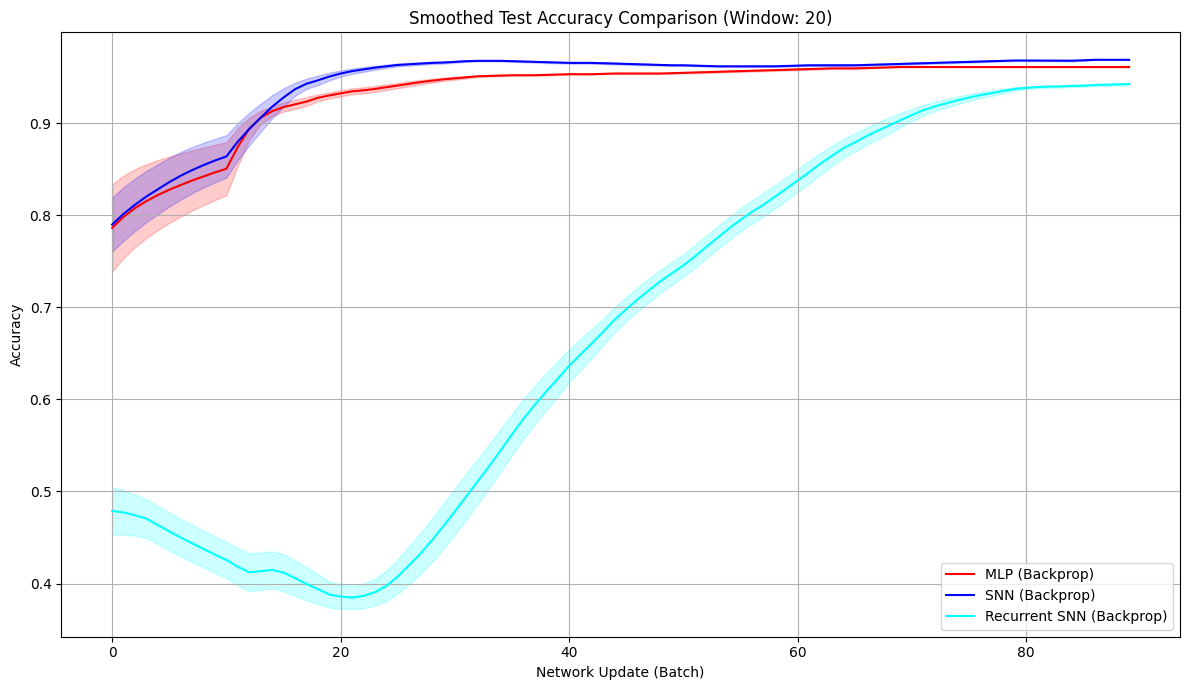

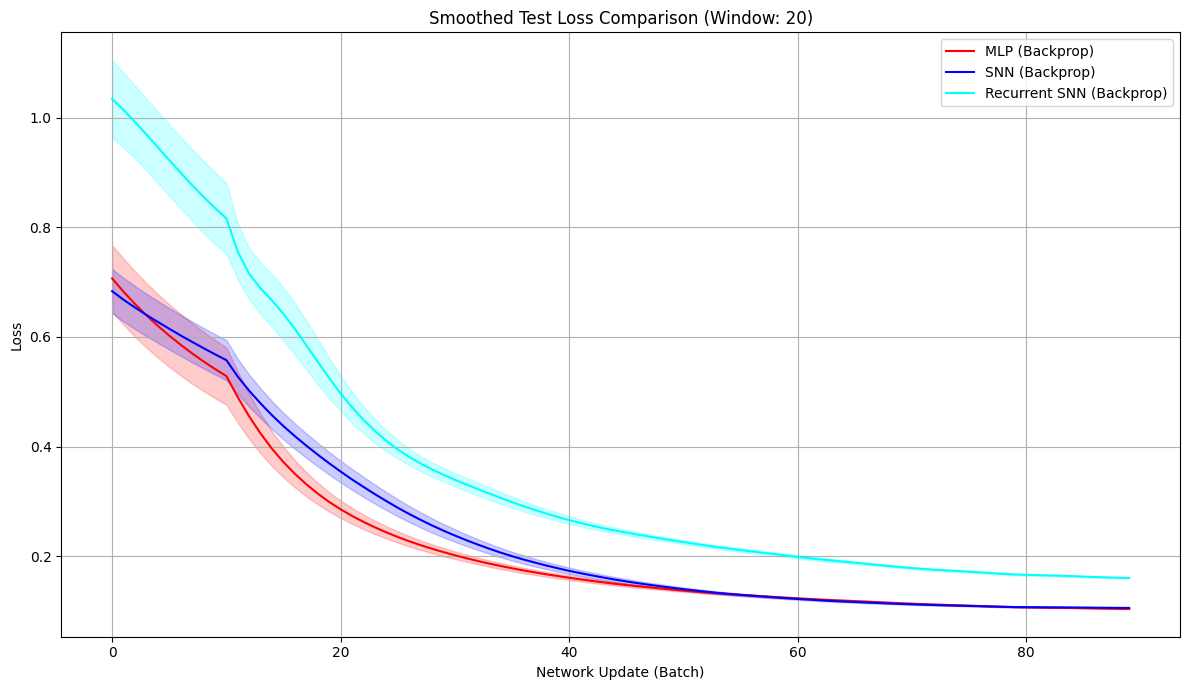

In [203]:
#@title whole thing in one cell

import os
import io
import math
import random
import contextlib
import numpy as np
import scipy
import warnings
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt

# IPython dependencies (if running in a notebook)
try:
    from IPython.display import Image, SVG, display
except ImportError:
    pass

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms

# snntorch dependencies
try:
    import snntorch as snn
    from snntorch import spikeplot as splt
    from snntorch import spikegen
except ImportError:
    print("snnTorch not found. Installing...")
    import subprocess
    subprocess.check_call(["pip", "install", "snntorch", "--quiet"])
    import snntorch as snn
    from snntorch import spikeplot as splt
    from snntorch import spikegen

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

class Config():
    def __init__(self):
        self.BATCH_SIZE = 128
        self.NUM_EPOCHS = 10 # Speed up training
        self.NUM_INPUTS = np.int64(28**2) # 28x28 images
        self.NUM_OUTPUTS = 2 # Will be dynamically set based on num_desired_labels_for_all
        self.NUM_HIDDEN = 100
        self.ACTIVATION = "leaky"
        self.BIAS = True

        self.BETA = 0.8 # Slope for leaky relu on SNN
        self.NUM_SNN_TIMESTEPS = 25

        self.ADAM_BETA = (0.9, 0.999)
        self.LEARNING_RULE = 3e-4
        self.DELAY_MEAN = 0.0 # Add DELAY_MEAN as a hyperparameter
        self.NUM_DESIRED_LABELS = 3 # Add NUM_DESIRED_LABELS as a hyperparameter

config = Config()

def download_mnist(train_prop=0.8, keep_prop=0.5, neuromatch_magic_normalize = 1):
    valid_prop = 1 - train_prop
    discard_prop = 1 - keep_prop

    if neuromatch_magic_normalize:
        norm_func = transforms.Normalize((0.1307,), (0.3081,))
    else:
        norm_func = transforms.Normalize((0,), (1,))

    transform = transforms.Compose([
              transforms.Resize((28, 28)),
              transforms.Grayscale(),
              transforms.ToTensor(),
              norm_func
              ])

    with contextlib.redirect_stdout(io.StringIO()):
        full_train_set = torchvision.datasets.MNIST(
            root="./data/", train=True, download=True, transform=transform,
        )
        full_test_set = torchvision.datasets.MNIST(
            root="./data/", train=False, download=True, transform=transform,
        )

    train_set, valid_set, _ = torch.utils.data.random_split(
        full_train_set,
        [train_prop * keep_prop, valid_prop * keep_prop, discard_prop]
    )
    test_set, _ = torch.utils.data.random_split(
        full_test_set,
        [keep_prop, discard_prop]
    )

    print("Number of examples retained:")
    print(f"  {len(train_set)} (training)")
    print(f"  {len(valid_set)} (validation)")
    print(f"  {len(test_set)} (test)")

    return train_set, valid_set, test_set

train_set, valid_set, test_set = download_mnist(train_prop=0.65,
                                                keep_prop=0.1,
                                                neuromatch_magic_normalize = 1)

BATCH_SIZE = config.BATCH_SIZE
train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
valid_loader = torch.utils.data.DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

def apply_probabilistic_delayed_labels(original_labels, num_examples, delay_mean=1.0):
    """
    Applies a probabilistic forward shift to labels with conflict resolution.

    Args:
        original_labels (torch.Tensor): The original labels for the batch.
        num_examples (int): The number of examples in the batch (determines the size
                            of the delayed labels array).
        delay_mean (float): The mean (lambda) for the Poisson distribution to determine
                            the delay amount for each label.

    Returns:
        torch.Tensor: A tensor of the new, probabilistically delayed labels.
                      Labels that are pushed out of bounds or for unassigned slots are -1.
    """
    delayed_labels = torch.full((num_examples,), -1, dtype=torch.long)
    label_delay_info = []

    for i, label in enumerate(original_labels):
        delay_amount = np.random.poisson(delay_mean)
        label_delay_info.append((i, delay_amount, label.item()))

    label_delay_info.sort(key=lambda x: x[0])

    occupied_slots = [False] * num_examples

    for original_idx, delay_amount, label_value in label_delay_info:
        desired_target_idx = original_idx + delay_amount

        current_target_idx = desired_target_idx
        while current_target_idx < num_examples and occupied_slots[current_target_idx]:
            current_target_idx += 1

        if current_target_idx < num_examples:
            delayed_labels[current_target_idx] = label_value
            occupied_slots[current_target_idx] = True

    return delayed_labels

def restrict_classes(dataset, classes=[6], keep=True):
  """
  Removes or keeps specified classes in a dataset.

  Arguments:
  - dataset (torch dataset or subset): Dataset with class targets.
  - classes (list): List of classes to keep or remove.
  - keep (bool): If True, the classes specified are kept. If False, they are
  removed.

  Returns:
  - new_dataset (torch dataset or subset): Datset restricted as specified.
  """

  if hasattr(dataset, "dataset"):
    indices = np.asarray(dataset.indices)
    targets = dataset.dataset.targets[indices]
    dataset = dataset.dataset
  else:
    indices = np.arange(len(dataset))
    targets = dataset.targets

  specified_idxs = np.isin(targets, np.asarray(classes))
  if keep:
    retain_indices = indices[specified_idxs]
  else:
    retain_indices = indices[~specified_idxs]

  new_dataset = torch.utils.data.Subset(dataset, retain_indices)

  return new_dataset

def create_delayed_dataloader(original_dataloader, delay_mean, num_desired_labels=None, classes_to_filter=None):
    """
    Creates a new DataLoader that yields probabilistically delayed labels for each batch.
    Optionally, filters the dataset to include only a specified number of unique classes.

    Args:
        original_dataloader (torch.utils.data.DataLoader): The original DataLoader.
        delay_mean (float): The mean (lambda) for the Poisson distribution to determine
                            the delay amount for each label, used by
                            apply_probabilistic_delayed_labels.
        num_desired_labels (int, optional): If specified and `classes_to_filter` is None,
                                            the dataset will be filtered to include only
                                            this many randomly selected unique classes.
                                            Labels for these classes will be remapped to be 0-indexed.
                                            Defaults to None.
        classes_to_filter (list, optional): A specific list of class labels to filter the
                                            dataset by. If provided, this list overrides the
                                            random sampling based on `num_desired_labels`.
                                            Defaults to None.

    Returns:
        torch.utils.data.DataLoader: A new DataLoader yielding (images, delayed_labels).
    """

    dataset_for_loader = original_dataloader.dataset
    selected_classes_map = None # Initialize to None

    if num_desired_labels is not None or classes_to_filter is not None:
        if classes_to_filter is not None:
            selected_classes = classes_to_filter
            num_actual_output_classes = len(selected_classes)
            print(f"Dataset will be filtered to include *pre-selected* classes: {sorted(selected_classes)}")
        else:
            if isinstance(original_dataloader.dataset, torch.utils.data.Subset):
                base_dataset = original_dataloader.dataset.dataset
                current_subset_indices = original_dataloader.dataset.indices
                if hasattr(base_dataset, 'targets'):
                    all_labels_in_current_scope = [base_dataset.targets[i].item() for i in current_subset_indices]
                elif hasattr(base_dataset, 'labels'):
                    all_labels_in_current_scope = [base_dataset.labels[i].item() for i in current_subset_indices]
                else:
                    raise AttributeError("Underlying base dataset has no 'targets' or 'labels' attribute for filtering.")
            else:
                if hasattr(original_dataloader.dataset, 'targets'):
                    all_labels_in_current_scope = original_dataloader.dataset.targets.tolist()
                elif hasattr(original_dataloader.dataset, 'labels'):
                    all_labels_in_current_scope = original_dataloader.dataset.labels.tolist()
                else:
                    raise AttributeError("Dataset has no 'targets' or 'labels' attribute for filtering.")

            unique_classes_in_scope = torch.unique(torch.tensor(all_labels_in_current_scope)).tolist()

            if num_desired_labels > len(unique_classes_in_scope):
                print(f"Warning: num_desired_labels ({num_desired_labels}) is greater than available unique classes ({len(unique_classes_in_scope)}). Using all available classes.")
                selected_classes = unique_classes_in_scope
                num_actual_output_classes = len(unique_classes_in_scope)
            else:
                selected_classes = random.sample(unique_classes_in_scope, num_desired_labels)
                num_actual_output_classes = num_desired_labels

            print(f"Dataset will be filtered to include only classes: {sorted(selected_classes)}")

        print(f"If you are using models, you might need to update `config.NUM_OUTPUTS` to {num_actual_output_classes} accordingly.")

        selected_classes_map = {original_label: new_label for new_label, original_label in enumerate(sorted(selected_classes))}
        dataset_for_loader = restrict_classes(original_dataloader.dataset, classes=selected_classes, keep=True)


    def custom_collate_fn(batch):
        images = torch.stack([item[0] for item in batch])
        original_labels_raw = [item[1] for item in batch]

        if selected_classes_map:
            original_labels_tensor = torch.tensor([
                selected_classes_map[label.item() if isinstance(label, torch.Tensor) else label]
                for label in original_labels_raw
            ])
        else:
            original_labels_tensor = torch.tensor(original_labels_raw)

        num_examples_in_batch = len(batch)
        delayed_labels = apply_probabilistic_delayed_labels(
            original_labels_tensor, num_examples_in_batch, delay_mean=delay_mean
        )

        return images, delayed_labels

    dataloader_kwargs = {
        'dataset': dataset_for_loader,
        'num_workers': original_dataloader.num_workers,
        'collate_fn': custom_collate_fn,
        'pin_memory': original_dataloader.pin_memory,
        'timeout': original_dataloader.timeout,
        'worker_init_fn': original_dataloader.worker_init_fn
    }

    dataloader_kwargs['batch_size'] = original_dataloader.batch_size
    dataloader_kwargs['drop_last'] = original_dataloader.drop_last
    dataloader_kwargs['shuffle'] = original_dataloader.shuffle if hasattr(original_dataloader, 'shuffle') else False

    if original_dataloader.batch_sampler is not None:
        warnings.warn("Original DataLoader has a custom `batch_sampler`. "
                      "For the filtered DataLoader, `batch_size`, `drop_last`, "
                      "and `shuffle` from the original DataLoader will be used "
                      "to create a standard internal sampler. The custom `batch_sampler` "
                      "will not be directly re-used.")

    return torch.utils.data.DataLoader(**dataloader_kwargs)

class MultiLayerPerceptron(torch.nn.Module):
    def __init__(self, num_inputs=config.NUM_INPUTS, num_hidden=config.NUM_HIDDEN, num_outputs=config.NUM_OUTPUTS, activation_type="leaky", bias=False):
        super().__init__()
        self.num_inputs = num_inputs
        self.num_hidden = num_hidden
        self.num_outputs = num_outputs
        self.bias = bias

        self.lin1 = torch.nn.Linear(num_inputs, num_hidden, bias=bias)
        self.lin2 = torch.nn.Linear(num_hidden, num_outputs, bias=bias)
        self.activation = torch.nn.LeakyReLU(config.BETA)

    def forward(self, X, y=None):
        h = self.activation(self.lin1(X.reshape(-1, self.num_inputs)))
        y_pred = self.lin2(h)
        return y_pred

class SNN_MLP(nn.Module):
    def __init__(self, num_outputs = config.NUM_OUTPUTS):
        super().__init__()
        self.fc1 = nn.Linear(config.NUM_INPUTS, config.NUM_HIDDEN)
        self.lif1 = snn.Leaky(beta=config.BETA)
        self.fc2 = nn.Linear(config.NUM_HIDDEN, num_outputs)
        self.lif2 = snn.Leaky(beta=config.BETA)

    def forward(self, x):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        spk2_rec, mem2_rec = [], []

        for step in range(config.NUM_SNN_TIMESTEPS):
            cur1 = self.fc1(x)
            spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            spk2_rec.append(spk2)
            mem2_rec.append(mem2)

        return torch.stack(spk2_rec, dim=0), torch.stack(mem2_rec, dim=0)

class SNN_rec(nn.Module):
    def __init__(self, num_outputs = config.NUM_OUTPUTS):
        super().__init__()
        self.fc1 = nn.Linear(config.NUM_INPUTS, config.NUM_HIDDEN)
        self.lif1 = snn.RLeaky(beta=config.BETA, linear_features=config.NUM_HIDDEN,
                                all_to_all=True
                               )
        self.fc2 = nn.Linear(config.NUM_HIDDEN, num_outputs)
        self.lif2 = snn.RLeaky(beta=config.BETA, linear_features=num_outputs,
                                all_to_all=True
                               )

    def forward(self, x):
        spk1,mem1 = self.lif1.init_rleaky()
        spk2,mem2 = self.lif1.init_rleaky()
        spk2_rec, mem2_rec = [], []

        for step in range(config.NUM_SNN_TIMESTEPS):
            cur1 = self.fc1(x)
            spk1, mem1 = self.lif1(cur1, spk1, mem1)
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, spk2, mem2)
            spk2_rec.append(spk2)
            mem2_rec.append(mem2)

        return torch.stack(spk2_rec, dim=0), torch.stack(mem2_rec, dim=0)

def train_snn_model(model, optimizer, train_loader, test_loader, num_epochs=config.NUM_EPOCHS):
    """
    Generic training loop for SNNs (works for both standard and Feedback Alignment).
    """
    model.to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=-1)
    loss_hist, test_loss_hist = [], []
    train_acc_hist, test_acc_hist = [], []
    num_steps = config.NUM_SNN_TIMESTEPS

    for epoch in range(num_epochs):
        for iter_counter, (data, targets) in enumerate(train_loader):
            data, targets = data.to(device), targets.to(device)

            # Forward pass
            model.train()
            spk_rec, mem_rec = model(data.view(config.BATCH_SIZE, -1))

            # Loss and updates
            loss_val = torch.zeros((1), dtype=torch.float, device=device)
            for step in range(num_steps):
                loss_val += criterion(mem_rec[step], targets)
            loss_val /= num_steps

            optimizer.zero_grad()
            loss_val.backward()
            optimizer.step()

            # Train Tracking
            loss_hist.append(loss_val.item())
            _, predicted_train_labels = spk_rec.sum(dim=0).max(1)
            train_acc = (predicted_train_labels == targets).float().mean().item()
            train_acc_hist.append(train_acc)

            # Test Tracking
            with torch.no_grad():
                model.eval()
                test_data, test_targets = next(iter(test_loader))
                test_data, test_targets = test_data.to(device), test_targets.to(device)

                test_spk, test_mem = model(test_data.view(config.BATCH_SIZE, -1))
                test_loss = torch.zeros((1), dtype=torch.float, device=device)
                for step in range(num_steps):
                     test_loss += criterion(test_mem[step], test_targets)
                test_loss /= num_steps
                test_loss_hist.append(test_loss.item())

                _, predicted_test_labels = test_spk.sum(dim=0).max(1)
                test_acc = (predicted_test_labels == test_targets).float().mean().item()
                test_acc_hist.append(test_acc)

    return loss_hist, test_loss_hist, train_acc_hist, test_acc_hist


def train_mlp_model(model, optimizer, train_loader, test_loader, num_epochs=config.NUM_EPOCHS):
    """
    Generic training loop for MLPs (works for both standard and Feedback Alignment).
    """
    model.to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=-1)
    loss_hist, test_loss_hist = [], []
    train_acc_hist, test_acc_hist = [], []

    for epoch in range(num_epochs):
        for iter_counter, (data, targets) in enumerate(train_loader):
            data, targets = data.to(device), targets.to(device)

            # Forward pass
            model.train()
            y_pred = model(data.view(config.BATCH_SIZE, -1))

            # Loss and Updates
            loss_val = criterion(y_pred, targets)
            optimizer.zero_grad()
            loss_val.backward()
            optimizer.step()

            # Train Tracking
            loss_hist.append(loss_val.item())
            predicted_train_labels = torch.argmax(y_pred, dim=1)
            train_acc = (predicted_train_labels == targets).float().mean().item()
            train_acc_hist.append(train_acc)

            # Test Tracking
            with torch.no_grad():
                model.eval()
                test_data, test_targets = next(iter(test_loader))
                test_data, test_targets = test_data.to(device), test_targets.to(device)

                test_y_pred = model(test_data.view(config.BATCH_SIZE, -1))
                test_loss = criterion(test_y_pred, test_targets)
                test_loss_hist.append(test_loss.item())

                predicted_test_labels = torch.argmax(test_y_pred, dim=1)
                test_acc = (predicted_test_labels == test_targets).float().mean().item()
                test_acc_hist.append(test_acc)

    return loss_hist, test_loss_hist, train_acc_hist, test_acc_hist

def smooth_curve_with_sem(data, window_size):
    """
    Computes a moving average and the Standard Error of the Mean (SEM)
    over a sliding window to generate smooth trendlines and shaded confidence regions.
    """
    if window_size <= 1:
        return np.array(data), np.zeros(len(data))
    if len(data) < window_size:
        return np.array([np.mean(data)] * len(data)), np.array([np.std(data)/np.sqrt(len(data))] * len(data))

    smoothed_data = []
    sem_data = []
    for i in range(len(data)):
        start_index = max(0, i - window_size // 2)
        end_index = min(len(data) - 1, i + window_size // 2)
        window = data[start_index:end_index + 1]

        smoothed_data.append(np.mean(window))
        sem_data.append(np.std(window) / np.sqrt(len(window)))

    return np.array(smoothed_data), np.array(sem_data)

# --- Training Execution ---

# Use DELAY_MEAN from config
delay_mean_param_2 = config.DELAY_MEAN # Adjust this value for different average delays
num_desired_labels_for_all = config.NUM_DESIRED_LABELS # Define the number of desired labels centrally

# --- Determine common selected classes from the train_loader's dataset ---
if isinstance(train_loader.dataset, torch.utils.data.Subset):
    base_train_dataset = train_loader.dataset.dataset
    if hasattr(base_train_dataset, 'targets'):
        all_labels_from_train_scope = [base_train_dataset.targets[i].item() for i in train_loader.dataset.indices]
    elif hasattr(base_train_dataset, 'labels'):
        all_labels_from_train_scope = [base_train_dataset.labels[i].item() for i in train_loader.dataset.indices]
    else:
        raise AttributeError("Train dataset has no 'targets' or 'labels' attribute for filtering.")
else:
    if hasattr(train_loader.dataset, 'targets'):
        all_labels_from_train_scope = train_loader.dataset.targets.tolist()
    elif hasattr(train_loader.dataset, 'labels'):
        all_labels_from_train_scope = train_loader.dataset.labels.tolist()
    else:
        raise AttributeError("Train dataset has no 'targets' or 'labels' attribute for filtering.")

unique_classes_from_train_set = torch.unique(torch.tensor(all_labels_from_train_scope)).tolist()

if num_desired_labels_for_all > len(unique_classes_from_train_set):
    common_selected_classes = unique_classes_from_train_set
    print(f"Warning: num_desired_labels ({num_desired_labels_for_all}) is greater than available unique classes in train set ({len(unique_classes_from_train_set)}). Using all available classes.")
else:
    common_selected_classes = random.sample(unique_classes_from_train_set, num_desired_labels_for_all)

print(f"Common classes selected for all loaders: {sorted(common_selected_classes)}")

# Dynamically set config.NUM_OUTPUTS based on the number of selected classes
config.NUM_OUTPUTS = len(common_selected_classes)
# Re-instantiate config here to ensure models use the updated NUM_OUTPUTS
config = Config()

# --- Create delayed dataloaders using the common selected classes ---
delayed_train_loader_2 = create_delayed_dataloader(
    train_loader, delay_mean=delay_mean_param_2, classes_to_filter=common_selected_classes
)
delayed_val_loader_2 = create_delayed_dataloader(
    valid_loader, delay_mean=delay_mean_param_2, classes_to_filter=common_selected_classes
)
delayed_test_loader_2 = create_delayed_dataloader(
    test_loader, delay_mean=delay_mean_param_2, classes_to_filter=common_selected_classes
)

# --- Instantiate models and optimizers ---
print("--> Initializing Backprop Models...")

mlp_bp = MultiLayerPerceptron(num_hidden=config.NUM_HIDDEN, bias=config.BIAS, num_outputs=config.NUM_DESIRED_LABELS).to(device)

snn_bp = SNN_MLP(num_outputs=config.NUM_DESIRED_LABELS).to(device)

rec_snn_bp = SNN_rec(num_outputs=config.NUM_DESIRED_LABELS).to(device)

mlp_bp_optimizer = torch.optim.Adam(mlp_bp.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)
snn_bp_optimizer = torch.optim.Adam(snn_bp.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)
rec_snn_bp_optimizer = torch.optim.Adam(rec_snn_bp.parameters(), lr=config.LEARNING_RULE, betas=config.ADAM_BETA)

# --- Train Models ---
print("Training Recurrent SNN (Backprop)...")
rec_snn_bp_loss, rec_snn_bp_tloss, rec_snn_bp_acc, rec_snn_bp_tacc = train_snn_model(
    rec_snn_bp, rec_snn_bp_optimizer, delayed_train_loader_2, delayed_test_loader_2
)

print("Training MLP (Backprop)...")
mlp_bp_loss, mlp_bp_tloss, mlp_bp_acc, mlp_bp_tacc = train_mlp_model(
    mlp_bp, mlp_bp_optimizer, delayed_train_loader_2, delayed_test_loader_2
)

print("Training SNN (Backprop)....")
snn_bp_loss, snn_bp_tloss, snn_bp_acc, snn_bp_tacc = train_snn_model(
    snn_bp, snn_bp_optimizer, delayed_train_loader_2, delayed_test_loader_2
)


# --- Plot Results ---
SMOOTHING_WINDOW = 20

# Smoothing accuracies and computing SEM
sm_mlp_bp_tacc, sem_mlp_bp_tacc = smooth_curve_with_sem(mlp_bp_tacc, SMOOTHING_WINDOW)
sm_snn_bp_tacc, sem_snn_bp_tacc = smooth_curve_with_sem(snn_bp_tacc, SMOOTHING_WINDOW)
sm_rec_snn_bp_tacc, sem_rec_snn_bp_tacc = smooth_curve_with_sem(rec_snn_bp_tacc, SMOOTHING_WINDOW)

# Plot 1: Smoothed Test Accuracy Comparison Plot with SEM
plt.figure(figsize=(12, 7))
epochs_range = np.arange(len(sm_mlp_bp_tacc))

plt.plot(epochs_range, sm_mlp_bp_tacc, label='MLP (Backprop)', color='red')
plt.fill_between(epochs_range, sm_mlp_bp_tacc - sem_mlp_bp_tacc, sm_mlp_bp_tacc + sem_mlp_bp_tacc, color='red', alpha=0.2)

plt.plot(epochs_range, sm_snn_bp_tacc, label='SNN (Backprop)', color='blue')
plt.fill_between(epochs_range, sm_snn_bp_tacc - sem_snn_bp_tacc, sm_snn_bp_tacc + sem_snn_bp_tacc, color='blue', alpha=0.2)

plt.plot(epochs_range, sm_rec_snn_bp_tacc, label='Recurrent SNN (Backprop)', color='cyan')
plt.fill_between(epochs_range, sm_rec_snn_bp_tacc - sem_rec_snn_bp_tacc, sm_rec_snn_bp_tacc + sem_rec_snn_bp_tacc, color='cyan', alpha=0.2)

plt.title(f'Smoothed Test Accuracy Comparison (Window: {SMOOTHING_WINDOW})')
plt.xlabel('Network Update (Batch)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Smoothing losses and computing SEM
sm_mlp_bp_tloss, sem_mlp_bp_tloss = smooth_curve_with_sem(mlp_bp_tloss, SMOOTHING_WINDOW)
sm_snn_bp_tloss, sem_snn_bp_tloss = smooth_curve_with_sem(snn_bp_tloss, SMOOTHING_WINDOW)
sm_rec_snn_bp_tloss, sem_rec_snn_bp_tloss = smooth_curve_with_sem(rec_snn_bp_tloss, SMOOTHING_WINDOW)

# Plot 2: Smoothed Test Loss Comparison Plot with SEM
plt.figure(figsize=(12, 7))

plt.plot(epochs_range, sm_mlp_bp_tloss, label='MLP (Backprop)', color='red')
plt.fill_between(epochs_range, sm_mlp_bp_tloss - sem_mlp_bp_tloss, sm_mlp_bp_tloss + sem_mlp_bp_tloss, color='red', alpha=0.2)

plt.plot(epochs_range, sm_snn_bp_tloss, label='SNN (Backprop)', color='blue')
plt.fill_between(epochs_range, sm_snn_bp_tloss - sem_snn_bp_tloss, sm_snn_bp_tloss + sem_snn_bp_tloss, color='blue', alpha=0.2)

plt.plot(epochs_range, sm_rec_snn_bp_tloss, label='Recurrent SNN (Backprop)', color='cyan')
plt.fill_between(epochs_range, sm_rec_snn_bp_tloss - sem_rec_snn_bp_tloss, sm_rec_snn_bp_tloss + sem_rec_snn_bp_tloss, color='cyan', alpha=0.2)

plt.title(f'Smoothed Test Loss Comparison (Window: {SMOOTHING_WINDOW})')
plt.xlabel('Network Update (Batch)')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()